# Ensemble B — 2016 Presidential Election (Clinton vs. Trump)

This notebook runs the ReCom ensemble scored on the 2016 presidential results (`PRES16D` / `PRES16R`).
Load the cleaned shapefile from `data/cleaned/pa_cleaned_precincts/` before running.


In [9]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from functools import partial

from gerrychain import Graph, Partition, Election, MarkovChain
from gerrychain.updaters import (
    Tally, cut_edges, cut_edges_by_part,
    boundary_nodes, exterior_boundaries, interior_boundaries, perimeter,
)
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from gerrychain.constraints import within_percent_of_ideal_population
from gerrychain.metrics import polsby_popper

## Step 1 — Load Cleaned Shapefile

Shape: (9150, 13)
Columns: ['COUNTYFP', 'TOTPOP', 'VAP', 'BVAP', 'APBVAP', 'WVAP', 'HVAP', 'PRES20D', 'PRES20R', 'PRES16D', 'PRES16R', 'SENDIST', 'geometry']
CRS: EPSG:32618
Districts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


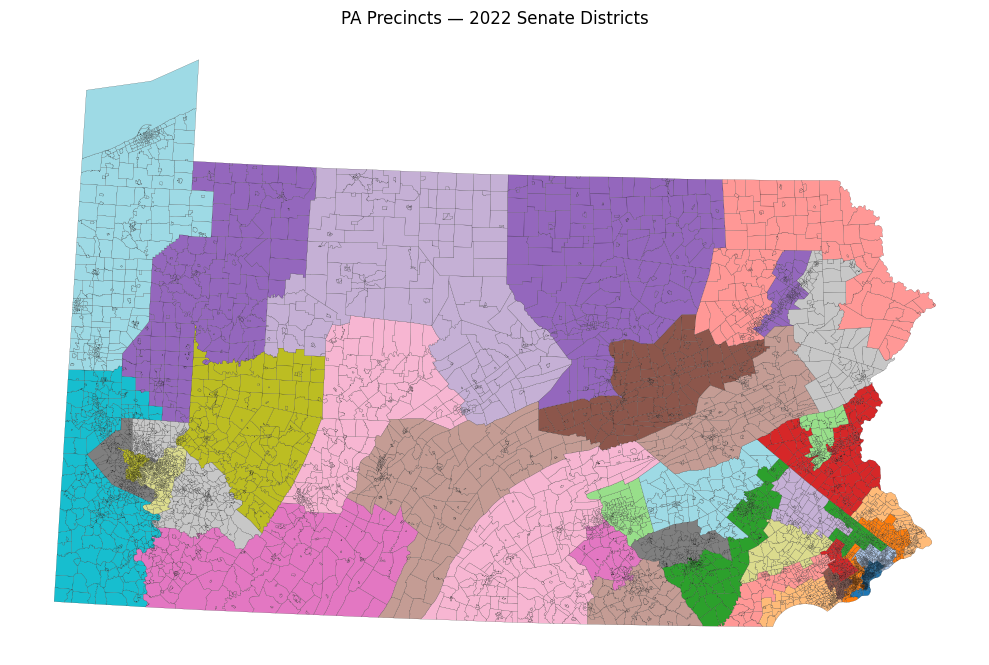

In [10]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
shp_path = os.path.join(BASE_DIR, "data", "cleaned", "pa_cleaned_precincts", "pa_cleaned_precincts.shp")

precincts = gpd.read_file(shp_path)
precincts["SENDIST"] = precincts["SENDIST"].astype(int)

print("Shape:", precincts.shape)
print("Columns:", list(precincts.columns))
print("CRS:", precincts.crs)
print("Districts:", sorted(precincts["SENDIST"].unique()))
precincts.plot(column="SENDIST", figsize=(10, 8), cmap="tab20", edgecolor="black", linewidth=0.1, legend=False)
plt.title("PA Precincts — 2022 Senate Districts")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 2 — Build Dual Graph and Initial Partition

In [11]:
graph = Graph.from_geodataframe(precincts)
print("Nodes:", graph.number_of_nodes(), "| Edges:", graph.number_of_edges())

election = Election("PRES16", {"Dem": "PRES16D", "Rep": "PRES16R"})

initial_partition = Partition(
    graph,
    assignment="SENDIST",
    updaters={
        "cut_edges": cut_edges,
        "cut_edges_by_part": cut_edges_by_part,
        "population": Tally("TOTPOP", alias="population"),
        "PRES16": election,
        "area": Tally("area", alias="area"),
        "boundary_nodes": boundary_nodes,
        "exterior_boundaries": exterior_boundaries,
        "interior_boundaries": interior_boundaries,
        "perimeter": perimeter,
    },
)

pops = sorted(initial_partition["population"].values())
print(f"Number of districts: {len(initial_partition)}")
print(f"Total population: {sum(pops):,}")
print(f"Ideal district population: {sum(pops)/len(initial_partition):,.0f}")
print(f"Min district pop: {min(pops):,}  |  Max: {max(pops):,}")
print(f"Enacted Dem seats (2016): {initial_partition['PRES16'].seats('Dem')}")

Nodes: 9150 | Edges: 25272
Number of districts: 50
Total population: 13,002,700
Ideal district population: 260,054
Min district pop: 248,775  |  Max: 270,863
Enacted Dem seats (2016): 23


## Step 3 — Configure and Run ReCom Ensemble

- **Population tolerance:** 5 % of ideal district size (enacted plan deviates up to ~4.3 %, so 2 % would reject the initial state)
- **Steps:** 1 000 (increase for publication-quality results)  
- **Proposal:** ReCom — random spanning tree, split on a population-balanced edge

In [12]:
POP_TOLERANCE = 0.05  # 5% — enacted plan deviates up to ~4.3% from ideal
NUM_STEPS = 75000

ideal_pop = sum(initial_partition["population"].values()) / len(initial_partition)

proposal = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_pop,
    epsilon=POP_TOLERANCE,
    node_repeats=2,
)

chain = MarkovChain(
    proposal=proposal,
    constraints=[within_percent_of_ideal_population(initial_partition, POP_TOLERANCE)],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=NUM_STEPS,
)

dem_seats_list = []
dem_vote_shares_list = []
cut_edges_list = []
polsby_popper_list = []

for i, partition in enumerate(chain):
    dem_seats_list.append(partition["PRES16"].seats("Dem"))
    dem_vote_shares_list.append(list(partition["PRES16"].percents("Dem")))
    cut_edges_list.append(len(partition["cut_edges"]))
    pp = polsby_popper(partition)
    polsby_popper_list.append([pp[k] for k in sorted(pp.keys())])
    if (i + 1) % 100 == 0:
        print(f"  step {i+1}/{NUM_STEPS}")

dem_seats = np.array(dem_seats_list)
dem_vote_shares = np.array(dem_vote_shares_list)
dem_vote_shares_sorted = np.sort(dem_vote_shares, axis=1)

print(f"\nDone. Collected {len(dem_seats)} plans.")
print(f"Dem seat range: {dem_seats.min()} – {dem_seats.max()}  |  median: {np.median(dem_seats):.0f}")

  step 100/75000
  step 200/75000
  step 300/75000
  step 400/75000
  step 500/75000
  step 600/75000
  step 700/75000
  step 800/75000
  step 900/75000
  step 1000/75000
  step 1100/75000
  step 1200/75000
  step 1300/75000
  step 1400/75000
  step 1500/75000
  step 1600/75000
  step 1700/75000
  step 1800/75000
  step 1900/75000
  step 2000/75000
  step 2100/75000
  step 2200/75000
  step 2300/75000
  step 2400/75000
  step 2500/75000
  step 2600/75000
  step 2700/75000
  step 2800/75000
  step 2900/75000
  step 3000/75000
  step 3100/75000
  step 3200/75000
  step 3300/75000
  step 3400/75000
  step 3500/75000
  step 3600/75000
  step 3700/75000
  step 3800/75000
  step 3900/75000
  step 4000/75000
  step 4100/75000
  step 4200/75000
  step 4300/75000
  step 4400/75000
  step 4500/75000
  step 4600/75000
  step 4700/75000
  step 4800/75000
  step 4900/75000
  step 5000/75000
  step 5100/75000
  step 5200/75000
  step 5300/75000
  step 5400/75000
  step 5500/75000
  step 5600/75000
 

In [13]:
POP_TOLERANCE = 0.05
NUM_STEPS_2 = 150000

proposal2 = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_pop,
    epsilon=POP_TOLERANCE,
    node_repeats=2,
)

chain2 = MarkovChain(
    proposal=proposal2,
    constraints=[within_percent_of_ideal_population(initial_partition, POP_TOLERANCE)],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=NUM_STEPS_2,
)

dem_seats_list_2 = []
dem_vote_shares_list_2 = []
cut_edges_list_2 = []
polsby_popper_list_2 = []

for i, partition in enumerate(chain2):
    dem_seats_list_2.append(partition["PRES16"].seats("Dem"))
    dem_vote_shares_list_2.append(list(partition["PRES16"].percents("Dem")))
    cut_edges_list_2.append(len(partition["cut_edges"]))
    pp = polsby_popper(partition)
    polsby_popper_list_2.append([pp[k] for k in sorted(pp.keys())])
    if (i + 1) % 200 == 0:
        print(f"  step {i+1}/{NUM_STEPS_2}")

dem_seats_2 = np.array(dem_seats_list_2)
dem_vote_shares_2 = np.array(dem_vote_shares_list_2)
dem_vote_shares_sorted_2 = np.sort(dem_vote_shares_2, axis=1)

print(f"\nDone. Collected {len(dem_seats_2)} plans.")
print(f"Dem seat range: {dem_seats_2.min()} – {dem_seats_2.max()}  |  median: {np.median(dem_seats_2):.0f}")

  step 200/150000
  step 400/150000
  step 600/150000
  step 800/150000
  step 1000/150000
  step 1200/150000
  step 1400/150000
  step 1600/150000
  step 1800/150000
  step 2000/150000
  step 2200/150000
  step 2400/150000
  step 2600/150000
  step 2800/150000
  step 3000/150000
  step 3200/150000
  step 3400/150000
  step 3600/150000
  step 3800/150000
  step 4000/150000
  step 4200/150000
  step 4400/150000
  step 4600/150000
  step 4800/150000
  step 5000/150000
  step 5200/150000
  step 5400/150000
  step 5600/150000
  step 5800/150000
  step 6000/150000
  step 6200/150000
  step 6400/150000
  step 6600/150000
  step 6800/150000
  step 7000/150000
  step 7200/150000
  step 7400/150000
  step 7600/150000
  step 7800/150000
  step 8000/150000
  step 8200/150000
  step 8400/150000
  step 8600/150000
  step 8800/150000
  step 9000/150000
  step 9200/150000
  step 9400/150000
  step 9600/150000
  step 9800/150000
  step 10000/150000
  step 10200/150000
  step 10400/150000
  step 10600/

## Step 4 — Plot Results

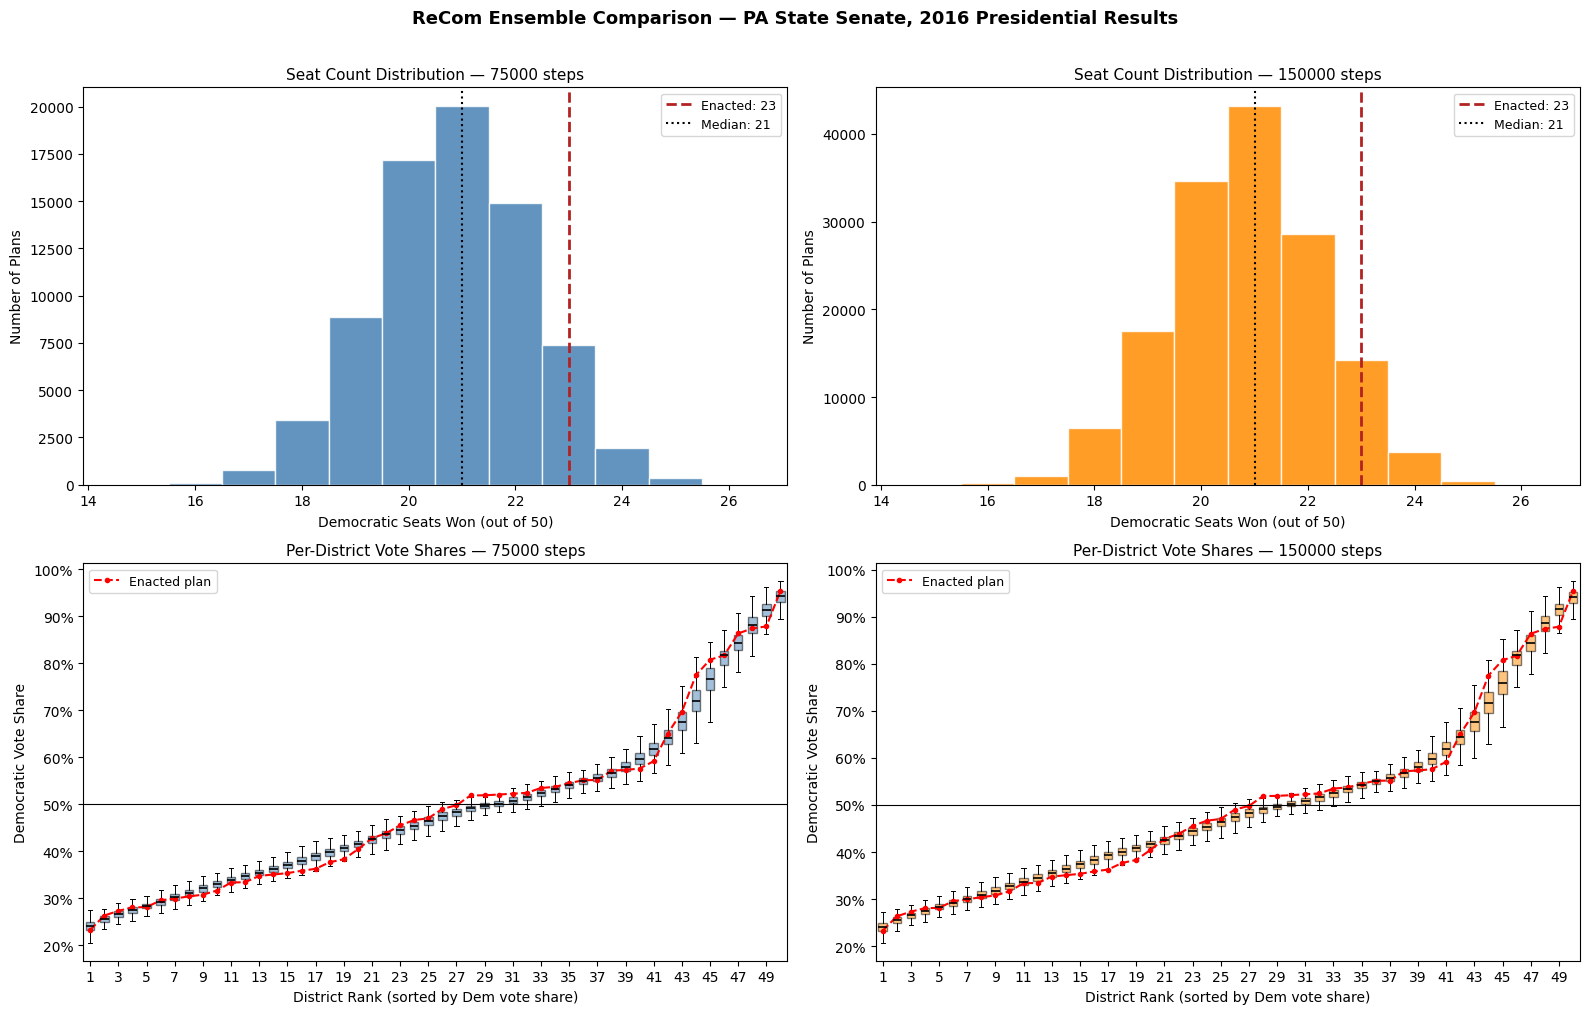

In [14]:
enacted_seats = initial_partition["PRES16"].seats("Dem")
enacted_percents = sorted(initial_partition["PRES16"].percents("Dem"))

# Rebuild clean arrays from both chain lists (safe to re-run even if variables were overwritten)
s1 = np.array(dem_seats_list)
vs1 = np.sort(np.array(dem_vote_shares_list), axis=1)
s2 = np.array(dem_seats_list_2)
vs2 = np.sort(np.array(dem_vote_shares_list_2), axis=1)

chains = [
    (s1, vs1, f"{NUM_STEPS} steps", "steelblue"),
    (s2, vs2, f"{NUM_STEPS_2} steps", "darkorange"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (seats, vs_sorted, label, color) in enumerate(chains):
    # --- row 0: seat-count histogram ---
    ax = axes[0, col]
    all_seats = np.concatenate([s1, s2])
    bins = np.arange(all_seats.min() - 0.5, all_seats.max() + 1.5, 1)
    ax.hist(seats, bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(enacted_seats, color="firebrick", linewidth=2, linestyle="--",
               label=f"Enacted: {enacted_seats}")
    ax.axvline(np.median(seats), color="black", linewidth=1.5, linestyle=":",
               label=f"Median: {np.median(seats):.0f}")
    ax.set_xlabel("Democratic Seats Won (out of 50)", fontsize=10)
    ax.set_ylabel("Number of Plans", fontsize=10)
    ax.set_title(f"Seat Count Distribution — {label}", fontsize=11)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # --- row 1: sorted vote-share box plot ---
    ax2 = axes[1, col]
    n_dist = vs_sorted.shape[1]
    ax2.boxplot(
        [vs_sorted[:, i] for i in range(n_dist)],
        positions=range(1, n_dist + 1),
        widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.5),
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(linewidth=0.7),
        capprops=dict(linewidth=0.7),
        showfliers=False,
    )
    ax2.plot(range(1, len(enacted_percents) + 1), enacted_percents,
             "r--o", markersize=3, linewidth=1.5, label="Enacted plan")
    ax2.axhline(0.5, color="black", linewidth=0.8)
    ax2.set_xlabel("District Rank (sorted by Dem vote share)", fontsize=10)
    ax2.set_ylabel("Democratic Vote Share", fontsize=10)
    ax2.set_title(f"Per-District Vote Shares — {label}", fontsize=11)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax2.legend(fontsize=9)
    ax2.set_xticks(range(1, n_dist + 1, 2))
    ax2.set_xticklabels(range(1, n_dist + 1, 2))

plt.suptitle("ReCom Ensemble Comparison — PA State Senate, 2016 Presidential Results",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

out_dir = os.path.join(BASE_DIR, "outputs", "figures")
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, "ensemble_B_seat_count_and_vote_shares.png"), dpi=150, bbox_inches="tight")
plt.show()

## Step 4b — Efficiency Gap & Cut Edges

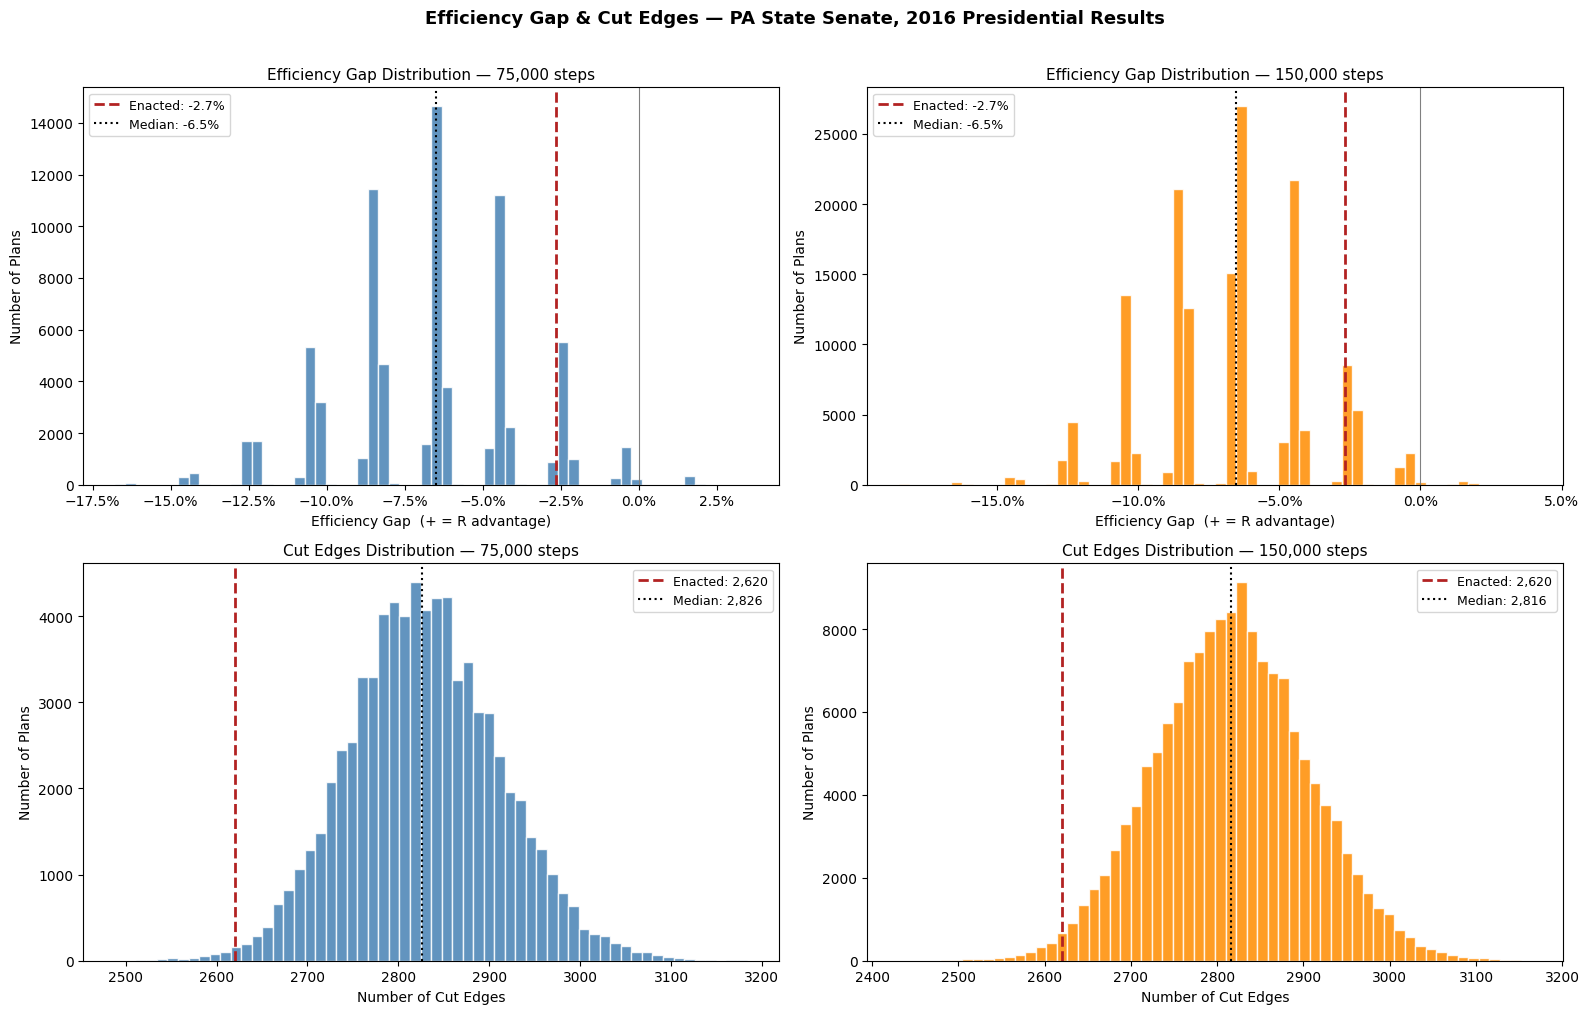

In [15]:
def efficiency_gap(vote_shares):
    """Positive = Republican advantage, negative = Democratic advantage."""
    vs = np.asarray(vote_shares)
    wasted_d = np.where(vs > 0.5, vs - 0.5, vs)
    wasted_r = np.where(vs > 0.5, 1 - vs, 0.5 - vs)
    return (wasted_r.sum() - wasted_d.sum()) / len(vs)

# EG computed from already-collected vote share data — no rerun needed
eg1 = np.array([efficiency_gap(row) for row in dem_vote_shares_list])
eg2 = np.array([efficiency_gap(row) for row in dem_vote_shares_list_2])

# Cut edges collected during the chain runs
ce1 = np.array(cut_edges_list)
ce2 = np.array(cut_edges_list_2)

# Enacted values
enacted_eg = efficiency_gap(list(initial_partition["PRES16"].percents("Dem")))
enacted_ce = len(initial_partition["cut_edges"])

chains = [
    (eg1, ce1, f"{NUM_STEPS:,} steps",   "steelblue"),
    (eg2, ce2, f"{NUM_STEPS_2:,} steps", "darkorange"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (eg, ce, label, color) in enumerate(chains):
    # --- row 0: efficiency gap ---
    ax = axes[0, col]
    ax.hist(eg, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(enacted_eg, color="firebrick", linewidth=2, linestyle="--",
               label=f"Enacted: {enacted_eg:.1%}")
    ax.axvline(np.median(eg), color="black", linewidth=1.5, linestyle=":",
               label=f"Median: {np.median(eg):.1%}")
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Efficiency Gap  (+ = R advantage)", fontsize=10)
    ax.set_ylabel("Number of Plans", fontsize=10)
    ax.set_title(f"Efficiency Gap Distribution — {label}", fontsize=11)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)

    # --- row 1: cut edges ---
    ax2 = axes[1, col]
    ax2.hist(ce, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax2.axvline(enacted_ce, color="firebrick", linewidth=2, linestyle="--",
                label=f"Enacted: {enacted_ce:,}")
    ax2.axvline(np.median(ce), color="black", linewidth=1.5, linestyle=":",
                label=f"Median: {np.median(ce):,.0f}")
    ax2.set_xlabel("Number of Cut Edges", fontsize=10)
    ax2.set_ylabel("Number of Plans", fontsize=10)
    ax2.set_title(f"Cut Edges Distribution — {label}", fontsize=11)
    ax2.legend(fontsize=9)

plt.suptitle("Efficiency Gap & Cut Edges — PA State Senate, 2016 Presidential Results",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

out_dir = os.path.join(BASE_DIR, "outputs", "figures")
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, "ensemble_B_efficiency_gap_cut_edges.png"), dpi=150, bbox_inches="tight")
plt.show()

## Step 4c — Polsby-Popper Compactness

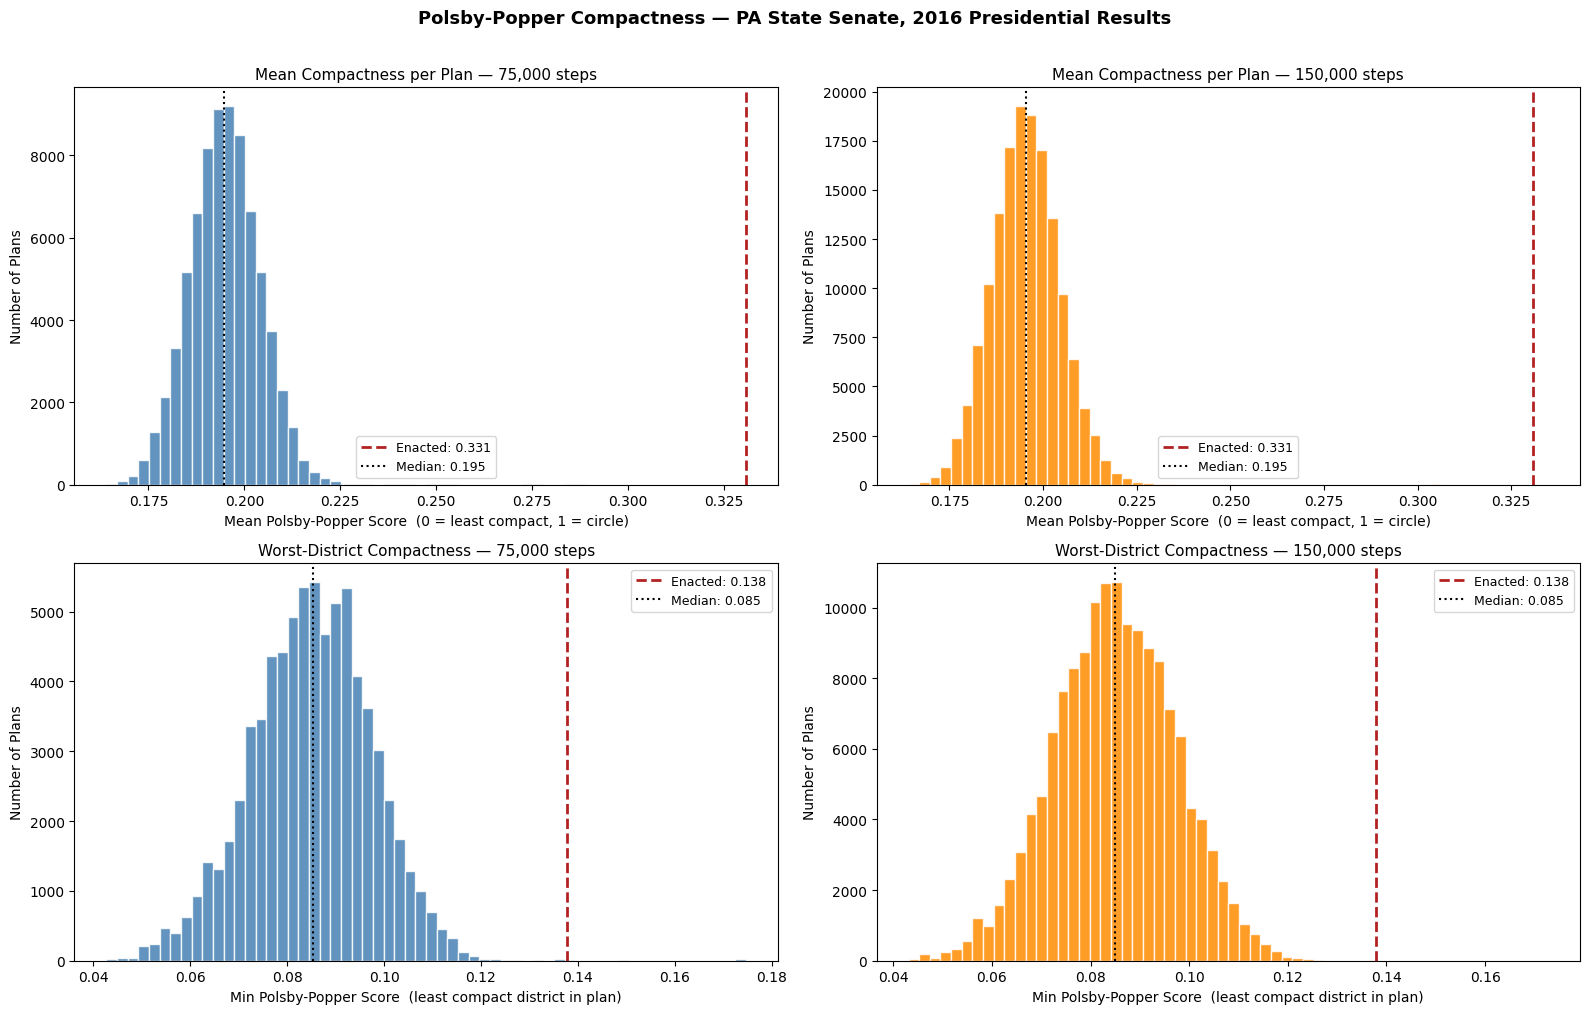

In [16]:
pp_arr1 = np.array(polsby_popper_list)    # shape (NUM_STEPS, 50)
pp_arr2 = np.array(polsby_popper_list_2)  # shape (NUM_STEPS_2, 50)

mean_pp1, min_pp1 = pp_arr1.mean(axis=1), pp_arr1.min(axis=1)
mean_pp2, min_pp2 = pp_arr2.mean(axis=1), pp_arr2.min(axis=1)

enacted_pp_vals = list(polsby_popper(initial_partition).values())
enacted_pp_mean = np.mean(enacted_pp_vals)
enacted_pp_min  = np.min(enacted_pp_vals)

chains = [
    (mean_pp1, min_pp1, f"{NUM_STEPS:,} steps",   "steelblue"),
    (mean_pp2, min_pp2, f"{NUM_STEPS_2:,} steps", "darkorange"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (mean_pp, min_pp, label, color) in enumerate(chains):
    # --- row 0: mean PP per plan ---
    ax = axes[0, col]
    ax.hist(mean_pp, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(enacted_pp_mean, color="firebrick", linewidth=2, linestyle="--",
               label=f"Enacted: {enacted_pp_mean:.3f}")
    ax.axvline(np.median(mean_pp), color="black", linewidth=1.5, linestyle=":",
               label=f"Median: {np.median(mean_pp):.3f}")
    ax.set_xlabel("Mean Polsby-Popper Score  (0 = least compact, 1 = circle)", fontsize=10)
    ax.set_ylabel("Number of Plans", fontsize=10)
    ax.set_title(f"Mean Compactness per Plan — {label}", fontsize=11)
    ax.legend(fontsize=9)

    # --- row 1: min PP per plan (least compact district) ---
    ax2 = axes[1, col]
    ax2.hist(min_pp, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax2.axvline(enacted_pp_min, color="firebrick", linewidth=2, linestyle="--",
                label=f"Enacted: {enacted_pp_min:.3f}")
    ax2.axvline(np.median(min_pp), color="black", linewidth=1.5, linestyle=":",
                label=f"Median: {np.median(min_pp):.3f}")
    ax2.set_xlabel("Min Polsby-Popper Score  (least compact district in plan)", fontsize=10)
    ax2.set_ylabel("Number of Plans", fontsize=10)
    ax2.set_title(f"Worst-District Compactness — {label}", fontsize=11)
    ax2.legend(fontsize=9)

plt.suptitle("Polsby-Popper Compactness — PA State Senate, 2016 Presidential Results",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

out_dir = os.path.join(BASE_DIR, "outputs", "figures")
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, "ensemble_B_polsby_popper.png"), dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — Save Ensemble Results

In [17]:
out_dir = os.path.join(BASE_DIR, "data", "ensemble_results")
os.makedirs(out_dir, exist_ok=True)

# --- Chain 1 (75k steps) ---
pd.DataFrame({"dem_seats": dem_seats_list}).to_csv(
    os.path.join(out_dir, "ensemble_B_75000_seats.csv"), index=False
)
pd.DataFrame(np.sort(np.array(dem_vote_shares_list), axis=1),
             columns=[f"dist_{i+1}" for i in range(50)]).to_csv(
    os.path.join(out_dir, "ensemble_B_75000_vote_shares.csv"), index=False
)
pd.DataFrame({"cut_edges": cut_edges_list}).to_csv(
    os.path.join(out_dir, "ensemble_B_75000_cut_edges.csv"), index=False
)
pd.DataFrame(np.array(polsby_popper_list),
             columns=[f"dist_{i+1}" for i in range(50)]).to_csv(
    os.path.join(out_dir, "ensemble_B_75000_polsby_popper.csv"), index=False
)

# --- Chain 2 (150k steps) ---
pd.DataFrame({"dem_seats": dem_seats_list_2}).to_csv(
    os.path.join(out_dir, "ensemble_B_150000_seats.csv"), index=False
)
pd.DataFrame(np.sort(np.array(dem_vote_shares_list_2), axis=1),
             columns=[f"dist_{i+1}" for i in range(50)]).to_csv(
    os.path.join(out_dir, "ensemble_B_150000_vote_shares.csv"), index=False
)
pd.DataFrame({"cut_edges": cut_edges_list_2}).to_csv(
    os.path.join(out_dir, "ensemble_B_150000_cut_edges.csv"), index=False
)
pd.DataFrame(np.array(polsby_popper_list_2),
             columns=[f"dist_{i+1}" for i in range(50)]).to_csv(
    os.path.join(out_dir, "ensemble_B_150000_polsby_popper.csv"), index=False
)

print("Saved results to", out_dir)

Saved results to c:\Users\elyas\Documents\Github\AI_For_Redistricting_Project\data\ensemble_results
